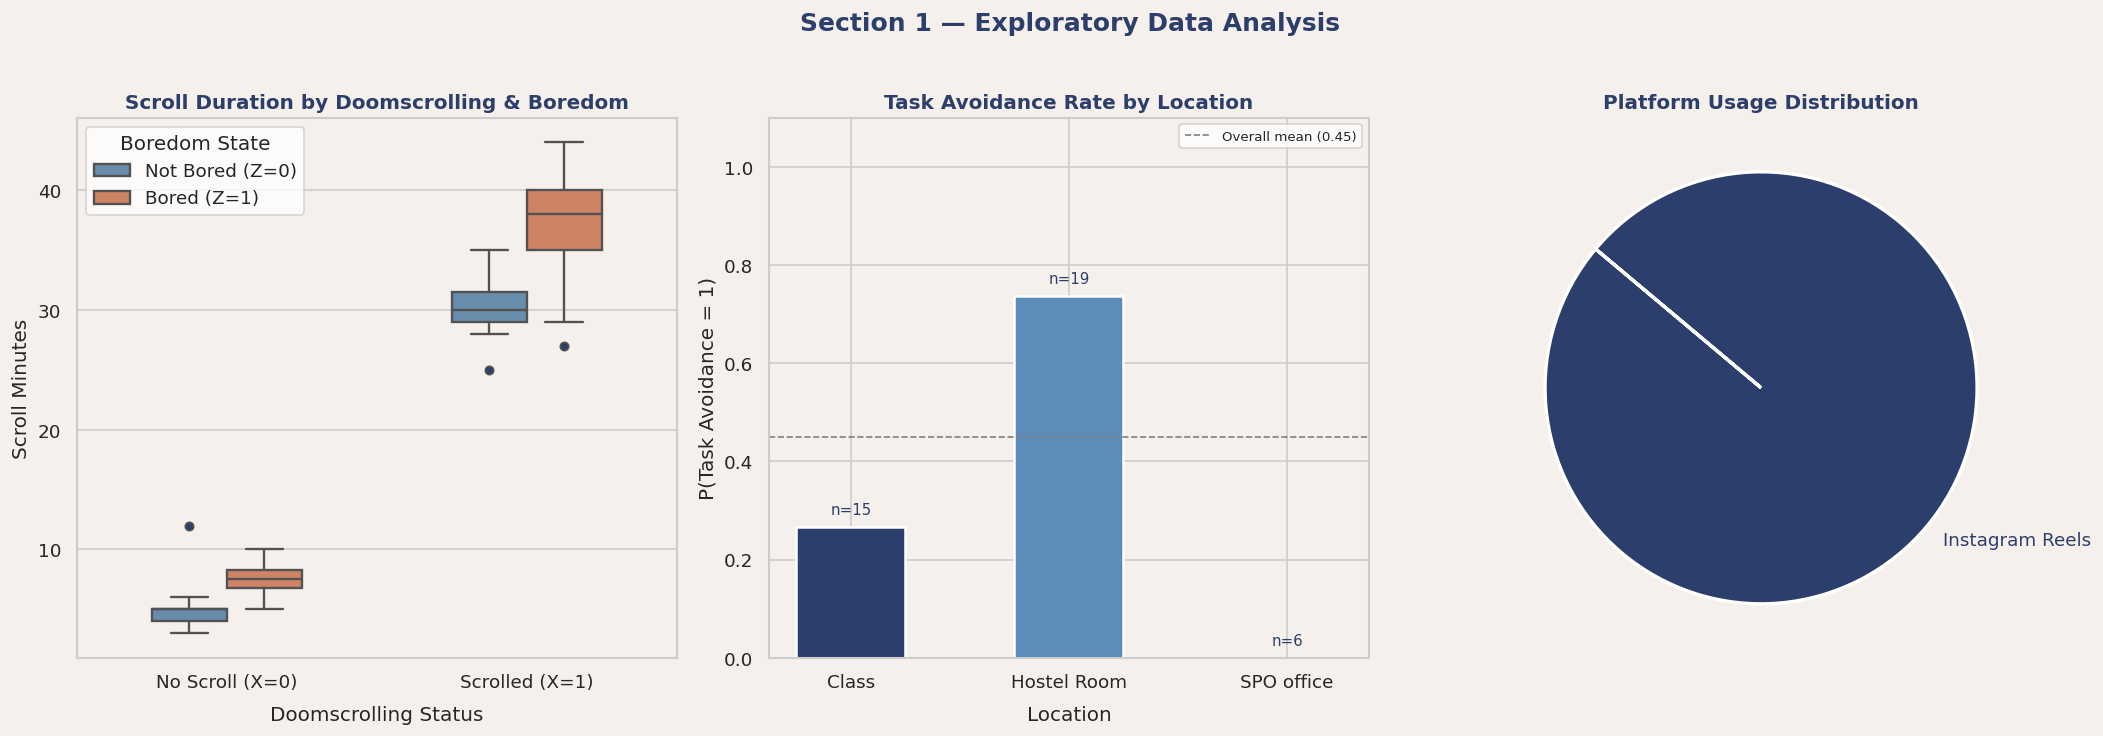

✔  Section 1 plots saved → section1_eda.png



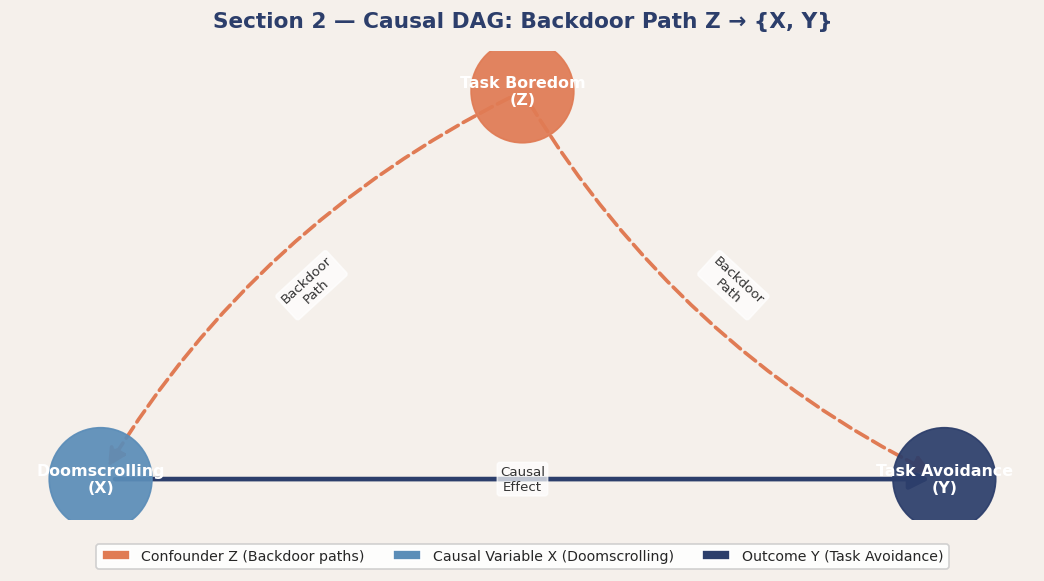

✔  Section 2 DAG saved → section2_dag.png

  SECTION 3 — PEARL'S DO-CALCULUS
  Backdoor Adjustment Formula
  P(Y|do(X)) = Σ_z  P(Y|X,Z=z) · P(Z=z)

── Step 1: Marginal P(Z) ──
   P(Z=1) = 24/40 = 0.6000
   P(Z=0) = 16/40 = 0.4000

── Step 2: Conditional P(Y=1 | X, Z) ──
   P(Y=1 | X=1, Z=1) = 16/16 = 1.0000
   P(Y=1 | X=1, Z=0) = 2/7 = 0.2857
   P(Y=1 | X=0, Z=1) = 0/8 = 0.0000
   P(Y=1 | X=0, Z=0) = 0/9 = 0.0000

── Step 3: Naive Observational Estimate (BIASED) ──
   P(Y=1 | X=1) = 18/23 = 0.7826
   ⚠  This is confounded by Z (Boredom).

── Step 4: Backdoor Adjustment Formula ──

   P(Y=1 | do(X=1))
   = P(Y=1|X=1,Z=1)·P(Z=1)  +  P(Y=1|X=1,Z=0)·P(Z=0)
   = 1.0000 × 0.6000  +  0.2857 × 0.4000
   = 0.6000  +  0.1143
   = 0.7143

   P(Y=1 | do(X=0))
   = P(Y=1|X=0,Z=1)·P(Z=1)  +  P(Y=1|X=0,Z=0)·P(Z=0)
   = 0.0000 × 0.6000  +  0.0000 × 0.4000
   = 0.0000  +  0.0000
   = 0.0000

  ★  P(Y=1 | do(X=1))        = 0.7143
  ★  P(Y=1 | do(X=0))        = 0.0000
  ★  Average Causal Effect    = 0.71

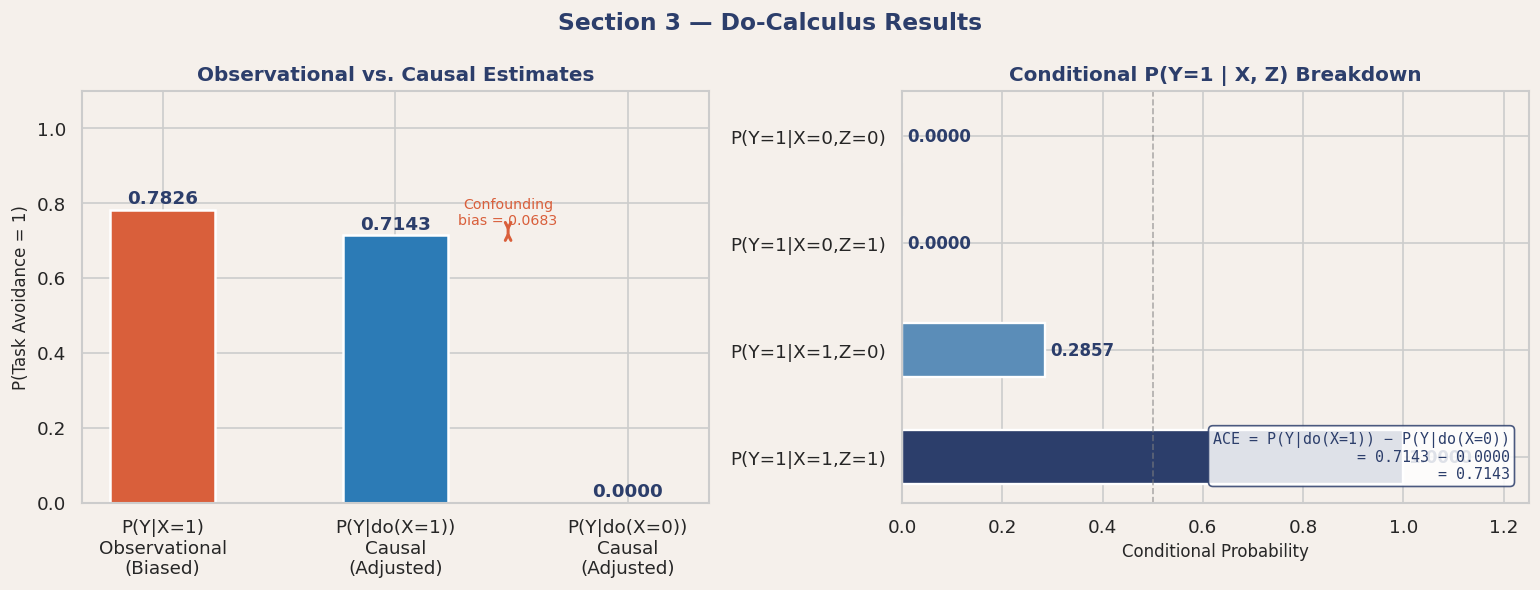


✔  Section 3 results plot saved → section3_docalculus.png
   [P_Y_DO_X1]     → 0.7143
   [P_Y_DO_X0]     → 0.0000
   [CAUSAL_EFFECT] → 0.7143


In [ ]:
# ============================================================
# CGS 616 - Final Assignment
# Causal Effect of Doomscrolling on Task Avoidance
# Author: Harsh Gour | Roll No: 230444
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from io import StringIO

# ── Load Data ────────────────────────────────────────────────
df = pd.read_excel("/content/sample_data/self_data (1).xlsx")

# ── Global theme ─────────────────────────────────────────────
sns.set_theme(style="whitegrid")
PALETTE = {"Bored (Z=1)": "#E07B54", "Not Bored (Z=0)": "#5B8DB8"}
ACCENT   = "#2C3E6B"
SOFT     = "#F5F0EB"

# ════════════════════════════════════════════════════════════
# SECTION 1 — EDA & VISUALISATIONS
# ════════════════════════════════════════════════════════════

fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.patch.set_facecolor(SOFT)
fig1.suptitle(
    "Section 1 — Exploratory Data Analysis",
    fontsize=15, fontweight="bold", color=ACCENT, y=1.02
)

# ── Plot 1A: Scroll Minutes by Doomscroll × Boredom ──────────
ax = axes[0]
df["Boredom_Label"] = df["Boredom_Z"].map({1: "Bored (Z=1)", 0: "Not Bored (Z=0)"})
df["Doomscroll_Label"] = df["Doomscroll_X"].map({1: "Scrolled (X=1)", 0: "No Scroll (X=0)"})

sns.boxplot(
    data=df,
    x="Doomscroll_Label",
    y="Scroll_Minutes",
    hue="Boredom_Label",
    palette=PALETTE,
    width=0.5,
    linewidth=1.4,
    flierprops=dict(marker="o", markerfacecolor=ACCENT, markersize=5),
    ax=ax
)
ax.set_title("Scroll Duration by Doomscrolling & Boredom", fontweight="bold", color=ACCENT)
ax.set_xlabel("Doomscrolling Status", labelpad=8)
ax.set_ylabel("Scroll Minutes")
ax.legend(title="Boredom State", framealpha=0.8)
ax.set_facecolor(SOFT)

# ── Plot 1B: Task Avoidance Rate by Location ──────────────────
ax = axes[1]
avoid_by_loc = (
    df.groupby("Location")["Task_Avoidance_Y"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "Avoidance_Rate", "count": "N"})
)
bars = ax.bar(
    avoid_by_loc["Location"],
    avoid_by_loc["Avoidance_Rate"],
    color=[ACCENT, "#5B8DB8", "#E07B54"],
    width=0.5,
    edgecolor="white",
    linewidth=1.5
)
# Annotate bars with sample sizes
for bar, n in zip(bars, avoid_by_loc["N"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"n={n}",
        ha="center", va="bottom", fontsize=9, color=ACCENT
    )
ax.set_title("Task Avoidance Rate by Location", fontweight="bold", color=ACCENT)
ax.set_xlabel("Location", labelpad=8)
ax.set_ylabel("P(Task Avoidance = 1)")
ax.set_ylim(0, 1.1)
ax.axhline(df["Task_Avoidance_Y"].mean(), color="grey", linestyle="--",
           linewidth=1, label=f"Overall mean ({df['Task_Avoidance_Y'].mean():.2f})")
ax.legend(fontsize=8, framealpha=0.8)
ax.set_facecolor(SOFT)

# ── Plot 1C: Platform Usage Distribution ─────────────────────
ax = axes[2]
platform_counts = df["Platform"].value_counts()
colors_pie = [ACCENT, "#5B8DB8", "#E07B54", "#A8C5A0"]
wedges, texts, autotexts = ax.pie(
    platform_counts,
    labels=platform_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(color=ACCENT)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax.set_title("Platform Usage Distribution", fontweight="bold", color=ACCENT)
ax.set_facecolor(SOFT)

plt.tight_layout()
plt.savefig("section1_eda.png", dpi=150, bbox_inches="tight", facecolor=SOFT)
plt.show()
print("✔  Section 1 plots saved → section1_eda.png\n")

# ════════════════════════════════════════════════════════════
# SECTION 2 — CAUSAL DAG (NetworkX)
# ════════════════════════════════════════════════════════════

fig2, ax = plt.subplots(figsize=(9, 5))
fig2.patch.set_facecolor(SOFT)
ax.set_facecolor(SOFT)

# Define nodes and directed edges
G = nx.DiGraph()
G.add_nodes_from(["Task Boredom\n(Z)", "Doomscrolling\n(X)", "Task Avoidance\n(Y)"])
G.add_edges_from([
    ("Task Boredom\n(Z)", "Doomscrolling\n(X)"),   # Z → X  (backdoor arrow)
    ("Task Boredom\n(Z)", "Task Avoidance\n(Y)"),   # Z → Y  (backdoor arrow)
    ("Doomscrolling\n(X)", "Task Avoidance\n(Y)"),  # X → Y  (causal path of interest)
])

# Fixed positions for a clean layout
pos = {
    "Task Boredom\n(Z)":    (0.5, 1.0),
    "Doomscrolling\n(X)":   (0.0, 0.0),
    "Task Avoidance\n(Y)":  (1.0, 0.0),
}

# Node styling
node_colors = {
    "Task Boredom\n(Z)":    "#E07B54",
    "Doomscrolling\n(X)":   "#5B8DB8",
    "Task Avoidance\n(Y)":  "#2C3E6B",
}
node_color_list = [node_colors[n] for n in G.nodes()]

nx.draw_networkx_nodes(
    G, pos, node_color=node_color_list, node_size=3800, ax=ax, alpha=0.93
)
nx.draw_networkx_labels(
    G, pos, font_size=9.5, font_color="white", font_weight="bold", ax=ax
)

# Draw causal edge (X → Y) in solid blue
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("Doomscrolling\n(X)", "Task Avoidance\n(Y)")],
    edge_color=ACCENT, arrows=True,
    arrowstyle="-|>", arrowsize=25,
    width=2.8, connectionstyle="arc3,rad=0.0", ax=ax
)
# Draw backdoor edges (Z → X, Z → Y) in dashed orange
nx.draw_networkx_edges(
    G, pos,
    edgelist=[
        ("Task Boredom\n(Z)", "Doomscrolling\n(X)"),
        ("Task Boredom\n(Z)", "Task Avoidance\n(Y)"),
    ],
    edge_color="#E07B54", arrows=True,
    arrowstyle="-|>", arrowsize=22,
    width=2.2, style="dashed", connectionstyle="arc3,rad=0.15", ax=ax
)

# Edge labels
edge_labels = {
    ("Task Boredom\n(Z)", "Doomscrolling\n(X)"): "Backdoor\nPath",
    ("Task Boredom\n(Z)", "Task Avoidance\n(Y)"): "Backdoor\nPath",
    ("Doomscrolling\n(X)", "Task Avoidance\n(Y)"): "Causal\nEffect",
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_size=8, font_color="#333333",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7), ax=ax
)

# Legend
legend_handles = [
    mpatches.Patch(facecolor="#E07B54", label="Confounder Z (Backdoor paths)"),
    mpatches.Patch(facecolor="#5B8DB8", label="Causal Variable X (Doomscrolling)"),
    mpatches.Patch(facecolor="#2C3E6B", label="Outcome Y (Task Avoidance)"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.12),
          ncol=3, fontsize=8.5, framealpha=0.9)

ax.set_title(
    "Section 2 — Causal DAG: Backdoor Path Z → {X, Y}",
    fontsize=13, fontweight="bold", color=ACCENT, pad=14
)
ax.axis("off")
plt.tight_layout()
plt.savefig("section2_dag.png", dpi=150, bbox_inches="tight", facecolor=SOFT)
plt.show()
print("✔  Section 2 DAG saved → section2_dag.png\n")

# ════════════════════════════════════════════════════════════
# SECTION 3 — DO-CALCULUS (Manual Backdoor Adjustment)
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  SECTION 3 — PEARL'S DO-CALCULUS")
print("  Backdoor Adjustment Formula")
print("  P(Y|do(X)) = Σ_z  P(Y|X,Z=z) · P(Z=z)")
print("=" * 60)

n = len(df)

# ── Step 1: Marginal distribution of the confounder Z ─────────
p_z1 = df["Boredom_Z"].mean()           # P(Z=1)
p_z0 = 1 - p_z1                         # P(Z=0)

print(f"\n── Step 1: Marginal P(Z) ──")
print(f"   P(Z=1) = {df['Boredom_Z'].sum()}/{n} = {p_z1:.4f}")
print(f"   P(Z=0) = {n - df['Boredom_Z'].sum()}/{n} = {p_z0:.4f}")

# ── Step 2: Conditional probabilities P(Y=1 | X, Z) ──────────
print(f"\n── Step 2: Conditional P(Y=1 | X, Z) ──")

def get_cond_prob(x_val, z_val):
    """Return P(Y=1 | X=x_val, Z=z_val) with counts."""
    mask = (df["Doomscroll_X"] == x_val) & (df["Boredom_Z"] == z_val)
    sub  = df[mask]
    n_sub = len(sub)
    if n_sub == 0:
        return 0.0, 0, 0
    n_y1 = sub["Task_Avoidance_Y"].sum()
    return n_y1 / n_sub, int(n_y1), n_sub

p_y1_x1_z1, ny1_x1z1, n_x1z1 = get_cond_prob(1, 1)
p_y1_x1_z0, ny1_x1z0, n_x1z0 = get_cond_prob(1, 0)
p_y1_x0_z1, ny1_x0z1, n_x0z1 = get_cond_prob(0, 1)
p_y1_x0_z0, ny1_x0z0, n_x0z0 = get_cond_prob(0, 0)

print(f"   P(Y=1 | X=1, Z=1) = {ny1_x1z1}/{n_x1z1} = {p_y1_x1_z1:.4f}")
print(f"   P(Y=1 | X=1, Z=0) = {ny1_x1z0}/{n_x1z0} = {p_y1_x1_z0:.4f}")
print(f"   P(Y=1 | X=0, Z=1) = {ny1_x0z1}/{n_x0z1} = {p_y1_x0_z1:.4f}")
print(f"   P(Y=1 | X=0, Z=0) = {ny1_x0z0}/{n_x0z0} = {p_y1_x0_z0:.4f}")

# ── Step 3: Naive observational estimate (biased) ─────────────
scroll_rows = df[df["Doomscroll_X"] == 1]
p_y1_given_x1_naive = scroll_rows["Task_Avoidance_Y"].mean()

print(f"\n── Step 3: Naive Observational Estimate (BIASED) ──")
print(f"   P(Y=1 | X=1) = {scroll_rows['Task_Avoidance_Y'].sum()}/{len(scroll_rows)}"
      f" = {p_y1_given_x1_naive:.4f}")
print(f"   ⚠  This is confounded by Z (Boredom).")

# ── Step 4: Backdoor Adjustment ───────────────────────────────
# P(Y=1 | do(X=1)) = P(Y=1|X=1,Z=1)·P(Z=1) + P(Y=1|X=1,Z=0)·P(Z=0)
p_y_do_x1 = p_y1_x1_z1 * p_z1 + p_y1_x1_z0 * p_z0
p_y_do_x0 = p_y1_x0_z1 * p_z1 + p_y1_x0_z0 * p_z0
ace        = p_y_do_x1 - p_y_do_x0
bias       = p_y1_given_x1_naive - p_y_do_x1

print(f"\n── Step 4: Backdoor Adjustment Formula ──")
print(f"\n   P(Y=1 | do(X=1))")
print(f"   = P(Y=1|X=1,Z=1)·P(Z=1)  +  P(Y=1|X=1,Z=0)·P(Z=0)")
print(f"   = {p_y1_x1_z1:.4f} × {p_z1:.4f}  +  {p_y1_x1_z0:.4f} × {p_z0:.4f}")
print(f"   = {p_y1_x1_z1 * p_z1:.4f}  +  {p_y1_x1_z0 * p_z0:.4f}")
print(f"   = {p_y_do_x1:.4f}")

print(f"\n   P(Y=1 | do(X=0))")
print(f"   = P(Y=1|X=0,Z=1)·P(Z=1)  +  P(Y=1|X=0,Z=0)·P(Z=0)")
print(f"   = {p_y1_x0_z1:.4f} × {p_z1:.4f}  +  {p_y1_x0_z0:.4f} × {p_z0:.4f}")
print(f"   = {p_y1_x0_z1 * p_z1:.4f}  +  {p_y1_x0_z0 * p_z0:.4f}")
print(f"   = {p_y_do_x0:.4f}")

print("\n" + "=" * 60)
print(f"  ★  P(Y=1 | do(X=1))        = {p_y_do_x1:.4f}")
print(f"  ★  P(Y=1 | do(X=0))        = {p_y_do_x0:.4f}")
print(f"  ★  Average Causal Effect    = {ace:.4f}")
print(f"  ★  Confounding Bias removed = {bias:.4f}")
print("=" * 60)

# ── Section 3 Summary Plot ────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.patch.set_facecolor(SOFT)
fig3.suptitle(
    "Section 3 — Do-Calculus Results",
    fontsize=14, fontweight="bold", color=ACCENT
)

# Left: Comparison bar chart
ax3a = axes3[0]
ax3a.set_facecolor(SOFT)
labels   = ["P(Y|X=1)\nObservational\n(Biased)",
            "P(Y|do(X=1))\nCausal\n(Adjusted)",
            "P(Y|do(X=0))\nCausal\n(Adjusted)"]
values   = [p_y1_given_x1_naive, p_y_do_x1, p_y_do_x0]
bar_cols = ["#D95F3B", "#2C7BB6", "#5B8DB8"]

bars3 = ax3a.bar(labels, values, color=bar_cols, width=0.45,
                  edgecolor="white", linewidth=1.5)
for bar, val in zip(bars3, values):
    ax3a.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.015,
              f"{val:.4f}", ha="center", fontsize=11,
              fontweight="bold", color=ACCENT)

ax3a.set_ylim(0, 1.1)
ax3a.set_ylabel("P(Task Avoidance = 1)", fontsize=10)
ax3a.set_title("Observational vs. Causal Estimates", fontweight="bold", color=ACCENT)

# Annotate bias arrow
ax3a.annotate(
    f"Confounding\nbias = {bias:.4f}",
    xy=(0.68, p_y_do_x1 + 0.01),
    xytext=(0.68, p_y1_given_x1_naive - 0.04),
    xycoords=("axes fraction", "data"),
    textcoords=("axes fraction", "data"),
    arrowprops=dict(arrowstyle="<->", color="#D95F3B", lw=1.8),
    ha="center", fontsize=8.5, color="#D95F3B"
)

# Right: ACE decomposition
ax3b = axes3[1]
ax3b.set_facecolor(SOFT)
categories = ["P(Y=1|X=1,Z=1)", "P(Y=1|X=1,Z=0)", "P(Y=1|X=0,Z=1)", "P(Y=1|X=0,Z=0)"]
cond_vals  = [p_y1_x1_z1, p_y1_x1_z0, p_y1_x0_z1, p_y1_x0_z0]
colors_cond = [ACCENT, "#5B8DB8", "#E07B54", "#F5C18A"]

bars_cond = ax3b.barh(categories, cond_vals, color=colors_cond,
                       edgecolor="white", linewidth=1.4, height=0.5)
for bar, val in zip(bars_cond, cond_vals):
    ax3b.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
              f"{val:.4f}", va="center", fontsize=10, fontweight="bold", color=ACCENT)
ax3b.set_xlim(0, 1.25)
ax3b.set_xlabel("Conditional Probability", fontsize=10)
ax3b.set_title("Conditional P(Y=1 | X, Z) Breakdown", fontweight="bold", color=ACCENT)
ax3b.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)

# ACE text box
textstr = (f"ACE = P(Y|do(X=1)) − P(Y|do(X=0))\n"
           f"    = {p_y_do_x1:.4f} − {p_y_do_x0:.4f}\n"
           f"    = {ace:.4f}")
props = dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor=ACCENT)
ax3b.text(0.97, 0.05, textstr, transform=ax3b.transAxes, fontsize=9,
          verticalalignment="bottom", horizontalalignment="right",
          bbox=props, color=ACCENT, family="monospace")

plt.tight_layout()
plt.savefig("section3_docalculus.png", dpi=150, bbox_inches="tight", facecolor=SOFT)
plt.show()
print("\n✔  Section 3 results plot saved → section3_docalculus.png")
print(f"   [P_Y_DO_X1]     → {p_y_do_x1:.4f}")
print(f"   [P_Y_DO_X0]     → {p_y_do_x0:.4f}")
print(f"   [CAUSAL_EFFECT] → {ace:.4f}")